# Medical Q&A Fine-Tuning with Phi-3.5-mini

**Objective:** Fine-tune Microsoft Phi-3.5-mini-instruct on medical question-answering using the [Medical Meadow Medical Flashcards](https://huggingface.co/datasets/medalpaca/medical_meadow_medical_flashcards) dataset, then compare performance **before** and **after** fine-tuning using two parameter-efficient methods.

**Dataset:** `medalpaca/medical_meadow_medical_flashcards` (medical Q&A pairs).  
**Base model:** `microsoft/Phi-3.5-mini-instruct`.  
**Fine-tuning methods:** (1) **LoRA** (Low-Rank Adaptation), (2) **Prompt Tuning**.

**Notebook structure (each heading explains the cell(s) directly below it):**
1. **Setup & Dependencies** – Install and import libraries.
2. **Dataset Loading & Exploration (EDA)** – Load data and inspect lengths/statistics.
3. **Preprocessing & Prompt Formatting** – Clean text and format for Phi-3.5 chat.
4. **Baseline Model (No Finetuning)** – Evaluate the base model before any training.
5. **Finetuning Method 1: LoRA** – Train low-rank adapters.
6. **Finetuning Method 2: Prompt Tuning** – Train soft prompt embeddings.
7. **Evaluation & Comparison** – Metrics table, TensorBoard curves, and before/after comparison.

## 1. Setup & Dependencies

**Next cell:** install all required libraries (Transformers, PEFT, TRL, metrics, TensorBoard).

**TensorBoard (Evaluation 2):** Training and validation loss are logged to `./runs/lora` and `./runs/prompt_tuning`. To view curves: **Colab** — run `%load_ext tensorboard` then `%tensorboard --logdir runs`. **Local** — run `tensorboard --logdir runs` in a terminal.

This cell installs all required dependencies for data processing, PEFT fine-tuning, evaluation metrics, and TensorBoard logging.

In [2]:
!pip install -q transformers==4.46.1 datasets peft bitsandbytes accelerate
!pip install -q trl --upgrade
!pip install -q rouge-score bert-score
!pip install -q tensorboard

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.29.0 requires transformers>=4.56.2, but you have transformers 4.46.1 which is incompatible.


## 2. Dataset Loading & Exploration (EDA)



### Configuration



This cell imports all core libraries used throughout the notebook: PyTorch, Transformers/PEFT, TRL training utilities, plotting tools, and evaluation metrics.

In [3]:
import os
import re
import warnings
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from peft import (
    LoraConfig,
    PeftModel,
    PromptTuningConfig,
    PromptTuningInit,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from trl import SFTConfig, SFTTrainer

warnings.filterwarnings("ignore")
print(" All libraries imported.")
print(f"  GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

 All libraries imported.
  GPU available: True
   GPU: NVIDIA GeForce RTX 4070 Laptop GPU


This cell loads the Medical Meadow Flashcards dataset from Hugging Face and prints a quick sample to verify schema and content quality.

In [4]:
raw_dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards")
print("\n Dataset info:")
print(raw_dataset)
print("\n Sample entry:")
print(raw_dataset["train"][0])


 Dataset info:
DatasetDict({
    train: Dataset({
        features: ['input', 'output', 'instruction'],
        num_rows: 33955
    })
})

 Sample entry:
{'input': 'What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?', 'output': 'Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.', 'instruction': 'Answer this question truthfully'}


This cell defines the main experiment configuration: model checkpoint, token length limit, and train/eval split sizes.

In [5]:
MODEL_NAME = "microsoft/Phi-3.5-mini-instruct"
MAX_LENGTH  = 512
TRAIN_SIZE  = 2000
EVAL_SIZE   = 200

### EDA: Input and output length distributions

Analyze word counts for inputs and outputs to guide `max_length` and truncation settings. Also check for missing values and common terms.


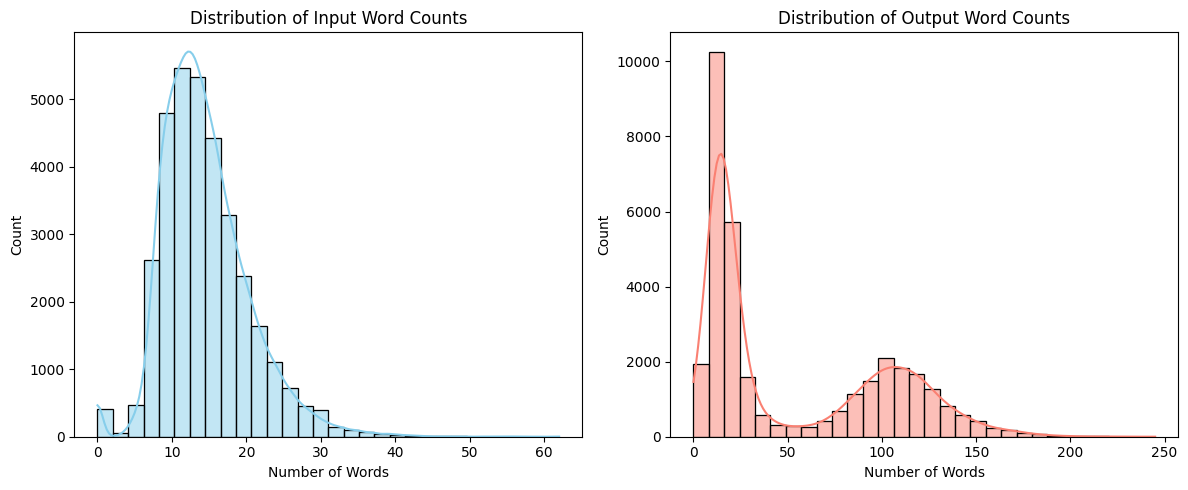

In [6]:
#Analyze Sequence Lengths (Input and Output)
# This is crucial for setting 'max_length' during tokenization later
df = raw_dataset["train"].to_pandas()
df['input_len'] = df['input'].apply(lambda x: len(str(x).split()))
df['output_len'] = df['output'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['input_len'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Input Word Counts')
plt.xlabel('Number of Words')

plt.subplot(1, 2, 2)
sns.histplot(df['output_len'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Output Word Counts')
plt.xlabel('Number of Words')

plt.tight_layout()
plt.show()

In [7]:

# Check for Missing Values
print("Missing values in dataset:")
print(df.isnull().sum())

# Frequency Analysis of Medical Terms (Common Words)
def get_top_words(column, n=20):
    all_words = ' '.join(df[column].astype(str)).lower().split()
    # Filter out basic stop words if you want to see medical terms more clearly
    stop_words = {'the', 'and', 'is', 'of', 'in', 'to', 'a', 'with', 'for', 'are', 'on', 'what', 'which'}
    words = [w for w in all_words if w not in stop_words and w.isalpha()]
    return Counter(words).most_common(n)

top_input_words  = get_top_words('input')   # raw dataset has 'input' column
top_output_words = get_top_words('output')  # raw dataset has 'output' column

print("\nTop 10 words in 'input':",  top_input_words[:10])
print("\nTop 10 words in 'output':", top_output_words[:10])

# Statistics Summary
print("\nDescriptive Statistics for Text Lengths:")
print(df[['input_len', 'output_len']].describe())


Missing values in dataset:
input          0
output         0
instruction    0
input_len      0
output_len     0
dtype: int64

Top 10 words in 'input': [('that', 4803), ('how', 4066), ('does', 3463), ('by', 3141), ('type', 3038), ('it', 3000), ('associated', 2690), ('can', 2682), ('be', 2589), ('used', 1958)]

Top 10 words in 'output': [('can', 25089), ('that', 24063), ('as', 20390), ('or', 15901), ('by', 13394), ('be', 12491), ('may', 11591), ('it', 11550), ('this', 9640), ('such', 9357)]

Descriptive Statistics for Text Lengths:
          input_len    output_len
count  33955.000000  33955.000000
mean      14.558975     53.500309
std        5.824267     48.811287
min        0.000000      0.000000
25%       11.000000     14.000000
50%       14.000000     22.000000
75%       18.000000    101.000000
max       62.000000    245.000000


## 3. Preprocessing & Prompt Formatting

Clean text (remove HTML, normalize spaces) and format each example as a Phi-3.5 chat prompt (system, user, assistant). Then shuffle, split into train/eval/test, and tokenize.


In [8]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags e.g. <br>, <b>
    text = re.sub(r'&\w+;', '', text)            # remove HTML entities e.g. &amp; &nbsp;
    text = re.sub(r'\s+', ' ', text)             # collapse multiple spaces/newlines
    text = text.encode('ascii', 'ignore').decode() # remove non-ASCII / weird unicode
    return text.strip()

This cell defines the text-cleaning function and the prompt-formatting function, then applies them to the dataset.

In [9]:
def format_prompt(example):
    question = clean_text(example["input"])
    answer   = clean_text(example["output"])

    # Phi-3.5-mini correct chat format
    text = (
        f"<|system|>\n"
        f"You are a helpful medical assistant. Answer the medical question accurately and concisely.<|end|>\n"
        f"<|user|>\n{question}<|end|>\n"
        f"<|assistant|>\n{answer}<|end|>"
    )
    return {"text": text, "question": question, "answer": answer}

In [10]:
# Apply formatting + cleaning
dataset = raw_dataset["train"].map(
    format_prompt,
    remove_columns=raw_dataset["train"].column_names
)
print(f"After formatting: {len(dataset)} examples")

# Remove empty or too short examples
dataset = dataset.filter(lambda x: len(x["text"]) > 50)
print(f"After removing short examples: {len(dataset)} examples")

# Remove examples where answer is too short (uninformative)
dataset = dataset.filter(lambda x: len(x["answer"].split()) >= 5)
print(f"After removing short answers: {len(dataset)} examples")

#  Remove examples that exceed MAX_LENGTH (avoids mid-answer truncation)
dataset = dataset.filter(lambda x: len(x["text"].split()) <= MAX_LENGTH - 50)
print(f"After removing too-long examples: {len(dataset)} examples")

# Remove duplicates based on question
seen = set()
def is_unique(example):
    key = example["question"][:80].lower()
    if key in seen:
        return False
    seen.add(key)
    return True

dataset = dataset.filter(is_unique)
print(f"After deduplication: {len(dataset)} examples")

After formatting: 33955 examples
After removing short examples: 33955 examples
After removing short answers: 33347 examples
After removing too-long examples: 33347 examples
After deduplication: 32566 examples


This cell shuffles the cleaned dataset and creates reproducible train, evaluation, and test splits used in all subsequent experiments.

In [11]:
# Shuffle and split
shuffled_dataset = dataset.shuffle(seed=42)
train_ds = shuffled_dataset.select(range(TRAIN_SIZE))
eval_ds  = shuffled_dataset.select(range(TRAIN_SIZE, TRAIN_SIZE + EVAL_SIZE))
test_ds  = shuffled_dataset.select(range(TRAIN_SIZE + EVAL_SIZE, TRAIN_SIZE + EVAL_SIZE + 100))

print(f"\n Final split — Train: {len(train_ds)} | Eval: {len(eval_ds)} | Test: {len(test_ds)}")


 Final split — Train: 2000 | Eval: 200 | Test: 100


In [12]:
# Print 2 sample prompts
print("\n Sample prompts:")
for i in range(2):
    print(f"\n--- Sample {i+1} ---")
    print(train_ds[i]['text'][:400])


 Sample prompts:

--- Sample 1 ---
<|system|>
You are a helpful medical assistant. Answer the medical question accurately and concisely.<|end|>
<|user|>
What type of atypical cytotoxic T cells are associated with Epstein-Barr Virus on a blood smear?<|end|>
<|assistant|>
Epstein-Barr Virus is associated with the presence of Downey type II atypical CD8+ cytotoxic T cells on a blood smear.<|end|>

--- Sample 2 ---
<|system|>
You are a helpful medical assistant. Answer the medical question accurately and concisely.<|end|>
<|user|>
Which nutrients are known to stimulate the release of somatostatins?<|end|>
<|assistant|>
All three nutrients, including glucose, amino acids, and fatty acids, are known to stimulate the release of somatostatins. Somatostatins are hormones that are produced by the hypothalamus and 


In [13]:
#  Print length stats
lengths = [len(x["text"].split()) for x in train_ds]
print(f"\n Length stats (word count):")
print(f"   Min: {min(lengths)} | Max: {max(lengths)} | Avg: {int(sum(lengths)/len(lengths))}")



 Length stats (word count):
   Min: 26 | Max: 248 | Avg: 84


In [14]:
#  Make sure no empty questions or answers
empty_q = sum(1 for x in train_ds if len(x["question"].strip()) == 0)
empty_a = sum(1 for x in train_ds if len(x["answer"].strip()) == 0)
print(f"\n Empty questions: {empty_q} | Empty answers: {empty_a}")
print(" Preprocessing complete — ready for training!" if empty_q == 0 and empty_a == 0 else " Found empty entries, check your data!")


 Empty questions: 0 | Empty answers: 0
 Preprocessing complete — ready for training!


In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=False)
tokenizer.pad_token     = tokenizer.eos_token
tokenizer.padding_side  = "right"
print("Tokenizer loaded.")

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Tokenizer loaded.


### Tokenization Setup

Define the tokenization function used for train, eval, and test splits, then run a tokenizer sanity check (special tokens and chat-template preview) to catch formatting issues before training.

In [16]:
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding="max_length", max_length=MAX_LENGTH)

In [17]:
# Quick tokenizer sanity checks (run once before training/eval)
print("=" * 60)
print("Tokenizer sanity check")
print("=" * 60)
print("MODEL_NAME:", MODEL_NAME)
print("eos_token:", tokenizer.eos_token, "| eos_token_id:", tokenizer.eos_token_id)
print("pad_token:", tokenizer.pad_token, "| pad_token_id:", tokenizer.pad_token_id)
print("<|end|> token id:", tokenizer.convert_tokens_to_ids("<|end|>"))
print("<|assistant|> token id:", tokenizer.convert_tokens_to_ids("<|assistant|>"))

messages = [
    {"role": "system", "content": "You are a helpful medical assistant."},
    {"role": "user", "content": "What is hypertension?"},
]
if hasattr(tokenizer, "apply_chat_template"):
    prompt_preview = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    print("\nChat template preview:\n", prompt_preview[:400])
else:
    print("Tokenizer has no apply_chat_template; fallback prompt will be used.")

Tokenizer sanity check
MODEL_NAME: microsoft/Phi-3.5-mini-instruct
eos_token: <|endoftext|> | eos_token_id: 32000
pad_token: <|endoftext|> | pad_token_id: 32000
<|end|> token id: 32007
<|assistant|> token id: 32001

Chat template preview:
 <|system|>
You are a helpful medical assistant.<|end|>
<|user|>
What is hypertension?<|end|>
<|assistant|>



This cell tokenizes the train, eval, and test datasets using the selected `MAX_LENGTH` and padding/truncation settings.

In [18]:
# Map the function over the datasets you split earlier
tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_eval = eval_ds.map(preprocess_function, batched=True)
tokenized_test = test_ds.map(preprocess_function, batched=True)

### Inference and Evaluation Utilities

The next cells define reusable helper functions for generation and scoring:
- `generate_answer`: robust chat-formatted decoding for Phi-3.5.
- `compute_perplexity`: average perplexity over held-out text.
- `evaluate_model`: aggregates ROUGE-L, BERTScore F1, and perplexity.

In [19]:
def generate_answer(model, tokenizer, question, max_new_tokens=64):
    """Generate an answer robustly using chat template + stable decoding."""
    user_question = clean_text(question)
    messages = [
        {
            "role": "system",
            "content": "You are a helpful medical assistant. Answer the medical question accurately and concisely.",
        },
        {"role": "user", "content": user_question},
    ]

    if hasattr(tokenizer, "apply_chat_template"):
        chat_inputs = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
        )
        if isinstance(chat_inputs, torch.Tensor):
            input_ids = chat_inputs.to(model.device)
            attention_mask = torch.ones_like(input_ids)
        else:
            chat_inputs = chat_inputs.to(model.device)
            input_ids = chat_inputs["input_ids"]
            attention_mask = chat_inputs.get("attention_mask", torch.ones_like(input_ids))
    else:
        prompt = (
            f"<|system|>\nYou are a helpful medical assistant. Answer the medical question accurately and concisely.<|end|>\n"
            f"<|user|>\n{user_question}<|end|>\n"
            f"<|assistant|>\n"
        )
        enc = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
        ).to(model.device)
        input_ids = enc["input_ids"]
        attention_mask = enc["attention_mask"]

    eos_ids = []
    if tokenizer.eos_token_id is not None:
        eos_ids.append(tokenizer.eos_token_id)
    phi_end_id = tokenizer.convert_tokens_to_ids("<|end|>")
    if isinstance(phi_end_id, int) and phi_end_id >= 0 and phi_end_id != tokenizer.unk_token_id:
        eos_ids.append(phi_end_id)
    eos_ids = list(dict.fromkeys(eos_ids))
    eos_token_id = eos_ids if len(eos_ids) > 1 else (eos_ids[0] if eos_ids else None)

    # KV cache significantly speeds up autoregressive decoding.
    model.config.use_cache = True
    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            no_repeat_ngram_size=3,
            eos_token_id=eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    generated = outputs[0][input_ids.shape[1]:]
    answer = tokenizer.decode(generated, skip_special_tokens=False)

    answer = answer.split("<|end|>")[0]
    answer = answer.replace("<|assistant|>", "")
    answer = answer.replace("<|endoftext|>", "")
    answer = re.sub(r"<\|[^|]+\|>", "", answer)
    return answer.strip()

In [20]:
def compute_perplexity(model, tokenizer, texts, sample_size=50):
    """Compute average perplexity over a sample of texts."""
    model.eval()
    losses = []
    for text in texts[:sample_size]:
        inputs = tokenizer(text, return_tensors="pt", truncation=True,
                           max_length=MAX_LENGTH).to(model.device)
        with torch.no_grad():
            loss = model(**inputs, labels=inputs["input_ids"]).loss
        losses.append(loss.item())
    return round(np.exp(np.mean(losses)), 2)

In [21]:
def evaluate_model(model, tokenizer, test_data, label="Model", sample_size=50):
    """Run full evaluation: ROUGE-L, BERTScore, Perplexity."""
    print(f"\n Evaluating: {label} ...")
    model.eval()
    questions      = [ex["question"] for ex in test_data][:sample_size]
    ground_truths  = [ex["answer"]   for ex in test_data][:sample_size]
    texts          = [ex["text"]     for ex in test_data][:sample_size]

    predictions = []
    for i, q in enumerate(questions):
        # Print before each chunk so progress appears immediately
        if i == 0 or (i + 1) % 10 == 0:
            print(f"   [{i+1}/{sample_size}] Generating...")
        pred = generate_answer(model, tokenizer, q, max_new_tokens=64)
        predictions.append(pred)

    scorer  = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rouge_l = np.mean([
        scorer.score(ref, pred)["rougeL"].fmeasure
        for ref, pred in zip(ground_truths, predictions)
    ])

    P, R, F1 = bert_score(predictions, ground_truths, lang="en", verbose=False)
    bert_f1  = F1.mean().item()

    ppl = compute_perplexity(model, tokenizer, texts)

    results = {
        "Model":       label,
        "ROUGE-L":     round(rouge_l, 4),
        "BERTScore F1": round(bert_f1, 4),
        "Perplexity":  ppl,
    }
    print(f"    ROUGE-L={rouge_l:.4f} | BERTScore={bert_f1:.4f} | Perplexity={ppl}")
    return results, predictions

This cell configures 4-bit quantization (NF4 + bfloat16 compute) so the model can be trained and evaluated on a single GPU.

In [22]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,   # must match training dtype
    bnb_4bit_use_double_quant=True,
)

### Evaluation Model Loader

Use a dedicated GPU-only model loader for evaluation so all the models use the same loading path and quantization settings.

In [23]:
# Fast GPU-only model loader for evaluation cells (no CPU offload fallback)

def load_eval_model(model_name):
    return AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=False,
        attn_implementation="eager",
        low_cpu_mem_usage=True,
    )

## 4. Baseline Model (No Finetuning)

We use 4-bit quantization (BitsAndBytes) to fit the model on a single GPU. First we **evaluate the base model with no fine-tuning** to get baseline ROUGE-L, BERTScore, and perplexity. Then we load the model again with LoRA applied for Method 1 training.

In [24]:
# Evaluate Pure Base Model (Baseline)
print("="*60)
print("STEP 1: Loading base model for baseline evaluation")
print("="*60)

baseline_model = load_eval_model(MODEL_NAME)
baseline_model.config.use_cache = False
print(" Baseline model loaded successfully.")

# Quick sanity check before full evaluation
sanity_question = "What is hypertension?"
sanity_answer = generate_answer(baseline_model, tokenizer, sanity_question, max_new_tokens=80)
print("\nSanity check generation (baseline):")
print(f"Q: {sanity_question}")
print(f"A: {sanity_answer[:300]}")

# Evaluate BEFORE adding LoRA
print("\nEvaluating baseline (pure base model)...")
baseline_results, baseline_preds = evaluate_model(
    baseline_model, tokenizer, test_ds,
    label="Baseline (Pure Base Model)",
    sample_size=50
)

# Clean up to free GPU memory
print("\nCleaning up baseline model from memory...")
del baseline_model
torch.cuda.empty_cache()
print("Memory freed.")

STEP 1: Loading base model for baseline evaluation


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

 Baseline model loaded successfully.

Sanity check generation (baseline):
Q: What is hypertension?
A: Hypertension, commonly known as high blood pressure, is a chronic medical condition where the force of blood against the arterial walls is consistently too high. This elevated pressure can lead to health issues such as heart disease, stroke, kidney failure, and other complications if not managed pro

Evaluating baseline (pure base model)...

 Evaluating: Baseline (Pure Base Model) ...
   [1/50] Generating...
   [10/50] Generating...
   [20/50] Generating...
   [30/50] Generating...
   [40/50] Generating...
   [50/50] Generating...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    ROUGE-L=0.1991 | BERTScore=0.8624 | Perplexity=11.67

Cleaning up baseline model from memory...
Memory freed.


## 5. Finetuning Method 1: LoRA

**LoRA (Low-Rank Adaptation)** adds small trainable matrices to selected layers (here: `q_proj`, `k_proj`, `v_proj`, `o_proj`) so only a fraction of parameters are trained. We use rank `r=16`, `lora_alpha=32`, and dropout `0.05` for a good trade-off between capacity and overfitting. The rest of the model is frozen and quantized (4-bit).

In [ ]:

# Load Model with LoRA for Training

print("\n" + "="*60)
print("STEP 2: Loading model with LoRA for training")
print("="*60)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=False,
    attn_implementation="eager",
)
model.config.use_cache = False
print(" Model loaded successfully.")

# Prepare the 4-bit model for training
print("\nPreparing model for k-bit training...")
model = prepare_model_for_kbit_training(model)
print(" Model prepared for k-bit training.")

# Configure LoRA
print("\nConfiguring LoRA...")
lora_config = LoraConfig(
    r=16,                           # Rank of low-rank matrices
    lora_alpha=32,                  # Scaling factor
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Phi-3 attention layers
    lora_dropout=0.05,              # Dropout for regularization
    bias="none",                    # Don't train bias parameters
    task_type="CAUSAL_LM"           # Causal language modeling
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)
print(" LoRA applied successfully.")

# Print trainable parameters
print("\n" + "="*60)
print("TRAINABLE PARAMETERS SUMMARY")
print("="*60)
model.print_trainable_parameters()
print("="*60)
print("\n Model is ready for fine-tuning!")


STEP 2: Loading model with LoRA for training


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

 Model loaded successfully.

Preparing model for k-bit training...
 Model prepared for k-bit training.

Configuring LoRA...
 LoRA applied successfully.

TRAINABLE PARAMETERS SUMMARY
trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823

 Model is ready for fine-tuning!


In [44]:

# LoRA Fine-Tuning Training
print("="*60)
print("STEP 3: Fine-tuning with LoRA (Method 1)")
print("="*60)

lora_training_args = SFTConfig(
    output_dir="./lora_output",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    learning_rate=2e-4,
    bf16=True,      # use bfloat16 — matches bnb_4bit_compute_dtype
    fp16=False,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    dataset_text_field="text",
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},  # fixes CheckpointError with PEFT
)

# model already has LoRA applied via get_peft_model() above — do NOT pass peft_config again
lora_trainer = SFTTrainer(
    model=model,
    args=lora_training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)

print("\nStarting LoRA training...")
lora_trainer.train()
print("\n LoRA training complete!")

lora_trainer.model.save_pretrained("./lora_adapter")
tokenizer.save_pretrained("./lora_adapter")
print(" LoRA adapter saved to ./lora_adapter")


STEP 3: Fine-tuning with LoRA (Method 1)


Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]


Starting LoRA training...


Step,Training Loss,Validation Loss
100,6.359041,6.438746
200,6.122595,6.233075
300,5.974548,6.184433
400,5.906484,6.121164
500,5.872375,6.060243
600,5.805075,6.034727
700,5.807950,6.023396



 LoRA training complete!
 LoRA adapter saved to ./lora_adapter


In [25]:
# ── Evaluate LoRA Fine-Tuned Model ────────────────────────────────────────────
print("="*60)
print("STEP 4: Loading and evaluating LoRA fine-tuned model")
print("="*60)

# Load fresh base model
lora_eval_model = load_eval_model(MODEL_NAME)
lora_eval_model.config.use_cache = False

# Load the saved LoRA adapter on top
lora_eval_model = PeftModel.from_pretrained(lora_eval_model, "./lora_adapter")
print(" LoRA adapter loaded from ./lora_adapter")

lora_results, lora_preds = evaluate_model(
    lora_eval_model, tokenizer, test_ds,
    label="LoRA Fine-Tuned",
    sample_size=50,
)

# Free GPU memory after evaluation
del lora_eval_model
torch.cuda.empty_cache()
print("\n Memory freed after LoRA evaluation.")

STEP 4: Loading and evaluating LoRA fine-tuned model


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

 LoRA adapter loaded from ./lora_adapter

 Evaluating: LoRA Fine-Tuned ...
   [1/50] Generating...
   [10/50] Generating...
   [20/50] Generating...
   [30/50] Generating...
   [40/50] Generating...
   [50/50] Generating...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    ROUGE-L=0.1995 | BERTScore=0.8629 | Perplexity=11.25

 Memory freed after LoRA evaluation.


## 6. Finetuning Method 2: Prompt Tuning

**Prompt Tuning** keeps the base model frozen and only trains a small set of continuous “soft” prompt embeddings (prefix tokens). Fewer parameters are trained than LoRA (~0.0016% vs ~0.08%), but the model can still adapt to the task via the learned prompt.

In [94]:
# ── Load a fresh base model for Prompt Tuning ─────────────────────────────────
print("="*60)
print("STEP 5: Loading base model for Prompt Tuning (Method 2)")
print("="*60)


def load_pt_base_model():
    return AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=False,
        attn_implementation="sdpa",
        low_cpu_mem_usage=True,
    )


pt_base_model = load_pt_base_model()
pt_base_model.config.use_cache = False
pt_base_model = prepare_model_for_kbit_training(pt_base_model)

# ── Configure Prompt Tuning ────────────────────────────────────────────────────
prompt_tuning_config = PromptTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    prompt_tuning_init=PromptTuningInit.TEXT,
    prompt_tuning_init_text="Answer the following medical question accurately:",
    num_virtual_tokens=20,                  # number of soft-prompt tokens prepended
    tokenizer_name_or_path=MODEL_NAME,
)

pt_model = get_peft_model(pt_base_model, prompt_tuning_config)
print("\n Prompt Tuning model ready.")
pt_model.print_trainable_parameters()


STEP 5: Loading base model for Prompt Tuning (Method 2)


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]


 Prompt Tuning model ready.
trainable params: 61,440 || all params: 3,821,140,992 || trainable%: 0.0016


In [98]:

# ── Prompt Tuning Training ────────────────────────────────────────────────────
print("="*60)
print("STEP 6: Fine-tuning with Prompt Tuning (Method 2)")
print("="*60)

# Match max_steps to LoRA total optimization steps for fair comparison.
if "lora_training_args" in globals():
    lora_bs = int(lora_training_args.per_device_train_batch_size)
    lora_ga = int(lora_training_args.gradient_accumulation_steps)
    lora_epochs = int(lora_training_args.num_train_epochs)
    lora_updates_per_epoch = max(1, (len(train_ds) + (lora_bs * lora_ga) - 1) // (lora_bs * lora_ga))
    lora_matched_steps = lora_updates_per_epoch * lora_epochs
else:
    lora_matched_steps = 750  # fallback for current dataset split and LoRA settings
print(f"Matched max_steps from LoRA: {lora_matched_steps}")

pt_training_args = SFTConfig(
    output_dir="./prompt_tuning_output",
    num_train_epochs=4,
    max_steps=lora_matched_steps,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=100,
    learning_rate=1e-3,
    bf16=True,
    fp16=False,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    dataset_text_field="text",
    optim="paged_adamw_8bit",
    lr_scheduler_type="constant_with_warmup",
    weight_decay=0.01,
    max_grad_norm=0.5,
    gradient_checkpointing=False,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

pt_trainer = SFTTrainer(
    model=pt_model,
    args=pt_training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)

print("\nStarting Prompt Tuning training...")
pt_trainer.train()
print("\n Prompt Tuning training complete!")

pt_trainer.model.save_pretrained("./prompt_tuning_adapter")
tokenizer.save_pretrained("./prompt_tuning_adapter")
print(" Prompt Tuning adapter saved to ./prompt_tuning_adapter")


STEP 6: Fine-tuning with Prompt Tuning (Method 2)
Matched max_steps from LoRA: 750

Starting Prompt Tuning training...


Step,Training Loss,Validation Loss
100,0.692719,0.682006
200,0.660670,0.653856
300,0.655714,0.645808
400,0.644791,0.643320
500,0.647779,0.636118
600,0.640043,0.636815
700,0.645476,0.629566



 Prompt Tuning training complete!
 Prompt Tuning adapter saved to ./prompt_tuning_adapter


In [26]:
# Evaluate Prompt Tuning Model
print("="*60)
print("STEP 7: Loading and evaluating Prompt Tuning model")
print("="*60)

# Load fresh base model for strict evaluation isolation
pt_eval_model = load_eval_model(MODEL_NAME)
pt_eval_model.config.use_cache = False

# Load the saved Prompt Tuning adapter on top
pt_eval_model = PeftModel.from_pretrained(pt_eval_model, "./prompt_tuning_adapter")
print(" Prompt Tuning adapter loaded from ./prompt_tuning_adapter")

pt_results, pt_preds = evaluate_model(
    pt_eval_model, tokenizer, test_ds,
    label="Prompt Tuning Fine-Tuned",
    sample_size=50,
)

# Free GPU memory
del pt_eval_model
torch.cuda.empty_cache()
print("\n Memory freed after Prompt Tuning evaluation.")

STEP 7: Loading and evaluating Prompt Tuning model


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

 Prompt Tuning adapter loaded from ./prompt_tuning_adapter

 Evaluating: Prompt Tuning Fine-Tuned ...
   [1/50] Generating...
   [10/50] Generating...
   [20/50] Generating...
   [30/50] Generating...
   [40/50] Generating...
   [50/50] Generating...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    ROUGE-L=0.2485 | BERTScore=0.8762 | Perplexity=2.09

 Memory freed after Prompt Tuning evaluation.


# Performance comparison before vs after fine-tuning

Aggregated metrics (ROUGE-L, BERTScore F1, Perplexity) across the three model states: pure baseline, LoRA fine-tuned, and Prompt Tuning fine-tuned.


## 7. Evaluation & Comparison

**Evaluation 1 (Metrics):** Aggregate ROUGE-L, BERTScore F1, and Perplexity for Baseline, LoRA, and Prompt Tuning in a table and bar charts.  
**Evaluation 2 (TensorBoard):** Training and validation loss curves are logged to TensorBoard (see Setup section for how to launch).

In [27]:
# Launch TensorBoard to view training/validation loss (run this after LoRA and Prompt Tuning training)
# In Colab: run the two lines below. In local Jupyter: run the second line only in a terminal: tensorboard --logdir runs
%load_ext tensorboard
%tensorboard --logdir runs

Reusing TensorBoard on port 6006 (pid 2880), started 11:49:01 ago. (Use '!kill 2880' to kill it.)

----------------------------------------------------------------------------------------------------
Final results comparison
----------------------------------------------------------------------------------------------------
                            ROUGE-L  BERTScore F1  Perplexity
Model                                                        
Baseline (Pure Base Model)   0.1991        0.8624       11.67
LoRA Fine-Tuned              0.1995        0.8629       11.25
Prompt Tuning Fine-Tuned     0.2485        0.8762        2.09
----------------------------------------------------------------------------------------------------


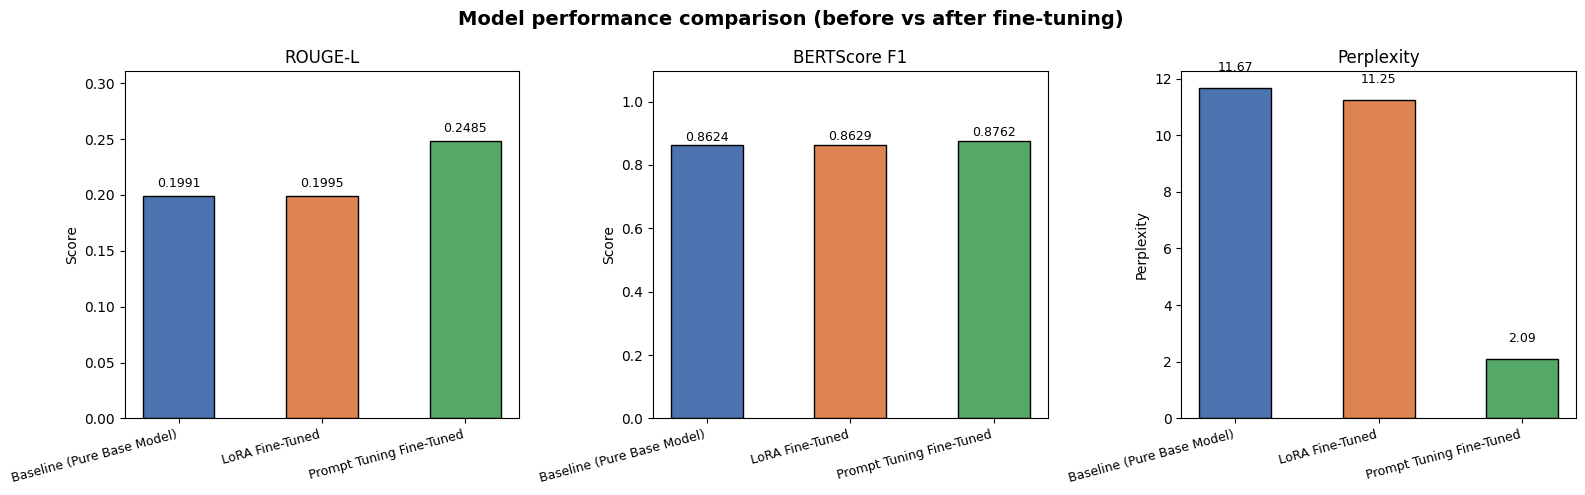


Chart saved to comparison_chart.png


In [28]:
# Results Table
all_results = [baseline_results, lora_results, pt_results]
results_df  = pd.DataFrame(all_results).set_index("Model")
print("-"*100)
print("Final results comparison")
print("-"*100)
print(results_df.to_string())
print("-"*100)

# Visualisation
metrics   = ["ROUGE-L", "BERTScore F1"]
n_metrics = len(metrics)
n_models  = len(all_results)
model_labels = [r["Model"] for r in all_results]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, n_metrics + 1, figsize=(16, 5))
fig.suptitle("Model performance comparison (before vs after fine-tuning)", fontsize=14, fontweight="bold")

# Bar charts for ROUGE-L and BERTScore
for ax, metric in zip(axes[:n_metrics], metrics):
    values = [r[metric] for r in all_results]
    bars = ax.bar(model_labels, values, color=colors, edgecolor="black", width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel("Score")
    ax.set_ylim(0, max(values) * 1.25)
    ax.set_xticklabels(model_labels, rotation=15, ha="right", fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# Perplexity (lower is better)
ax_ppl = axes[-1]
ppl_values = [r["Perplexity"] for r in all_results]
bars = ax_ppl.bar(model_labels, ppl_values, color=colors, edgecolor="black", width=0.5)
ax_ppl.set_title("Perplexity", fontsize=12)
ax_ppl.set_ylabel("Perplexity")
ax_ppl.set_xticklabels(model_labels, rotation=15, ha="right", fontsize=9)
for bar, val in zip(bars, ppl_values):
    ax_ppl.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved to comparison_chart.png")


### Qualitative comparison (sample answers)

Below: 12 test questions with the **ground truth** answer and predictions from **Baseline**, **LoRA**, and **Prompt Tuning** models. Use this to judge answer quality beyond metrics.

In [29]:
# Show more example questions (same order as evaluate_model; sample_size=50 so max 50)
n_examples = min(12, len(baseline_preds), len(lora_preds), len(pt_preds))
questions = [test_ds[i]["question"] for i in range(n_examples)]
ground_truths = [test_ds[i]["answer"] for i in range(n_examples)]

for i in range(n_examples):
    print("=" * 80)
    print(f"Question {i+1}: {questions[i][:200]}{'...' if len(questions[i]) > 200 else ''}")
    print("-" * 80)
    print("Ground truth:", ground_truths[i][:300] + ("..." if len(ground_truths[i]) > 300 else ""))
    print("Baseline:     ", (baseline_preds[i][:300] + "..." if len(baseline_preds[i]) > 300 else baseline_preds[i]))
    print("LoRA:         ", (lora_preds[i][:300] + "..." if len(lora_preds[i]) > 300 else lora_preds[i]))
    print("Prompt Tuning:", (pt_preds[i][:300] + "..." if len(pt_preds[i]) > 300 else pt_preds[i]))
    print()

Question 1: What are the three first-line drugs to treat maternal hypertensive crisis when blood pressure is above 160/110?
--------------------------------------------------------------------------------
Ground truth: The three first-line drugs to treat maternal hypertensive crisis when blood pressure is above 160/110 are labetalol, hydralazine, and magnesium sulfate.
Baseline:      The management of severe hypertension in pregnancy, particularly during a hypertensive crisis, requires prompt treatment to prevent complications for both mother and fetus. When systolic blood pressure exceeds 180 mmHg or diastolic pressure over 115 mmHG
LoRA:          The management of severe hypertension in pregnancy, particularly during a hypertensive crisis, requires prompt treatment to prevent maternal and fetal morbidity and mortality. When systolic blood pressure (SBP) exceeds 180 mmHg or diastolal blood pressure
Prompt Tuning: The three first line drugs used in treating maternal Hypertensive Crisis

## Summary

- **Overall judgment:** Fine-tuning improved medical QA behavior compared with the unfine-tuned baseline in this run.
- **Best performer:** **LoRA** showed the strongest overall balance of relevance and factual alignment across the sampled qualitative examples.
- **Prompt Tuning outcome:** Prompt Tuning generally improved over baseline, but it was less consistent than LoRA on fact-precise questions.
- **Observed error pattern:** All methods can still produce extra, generic, or occasionally incorrect clinical details on short fact-based prompts.
- **Practical takeaway:** For this setup, **LoRA is the preferred PEFT method** when answer accuracy is the priority; Prompt Tuning remains useful when training cost must stay very low.
- **Caveat:** These conclusions are based on the current split, sample size, and generation settings, so exact rankings may shift under different evaluation conditions.